In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.ensemble import RandomForestClassifier
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder
from interpret.glassbox import ExplainableBoostingClassifier
from sklearn.metrics import roc_auc_score, accuracy_score
df = pd.read_excel('/Users/milad/Desktop/Rulex/Directory_Data/MILAD_DATA_NEW 1.xlsx')

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/openpyxl/styles/stylesheet.py:237: UserWarning: Workbook contains no default style, apply openpyxl's default
  warn("Workbook contains no default style, apply openpyxl's default")


In [2]:
print(df.head())
print(df.describe())
print(df.info)
print(df.shape)
print(df.value_counts())

   "competitionId"  "gameweek"  "matchId"  "homeTeamId"  "awayTeamId"  \
0              102           1    1694390          4418         11944   
1              102           1    1694391          8731          6697   
2              102           2    1694392         11944          6697   
3              102           2    1694393          4418          8731   
4              102           3    1694394          6697          4418   

   "result"  "assists_home"  "assists_away"  "simple_passes_home_pct"  \
0  home_win               2               0                 71.351351   
1  away_win               0               1                 39.295775   
2      draw               0               1                 25.140713   
3  home_win               2               0                 62.748092   
4      draw               0               0                 61.919505   

   "simple_passes_away_pct"  ...  "throw_ins_def_home_pct"  \
0                 28.648649  ...                 52.380952  

In [28]:
df.columns = df.columns.str.replace('"', '')

cols_to_drop = [
    'matchId', 'homeTeamId', 'awayTeamId',
    'penalties_home_pct', 'penalties_away_pct'
]

X = df.drop(columns=['result'] + cols_to_drop)

# encode y
le = LabelEncoder()
y = le.fit_transform(df['result'])

''' one split for all models
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=0, stratify=y
)'''
print(y.shape)

(1941,)


In [4]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [5]:
clf = DecisionTreeClassifier(max_depth=6, criterion='log_loss')
clf.fit(X_train, y_train)

,criterion,'log_loss'
,splitter,'best'
,max_depth,6
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [38]:
print(clf.score(X_test, y_test))
print(clf.score(X_train, y_train))

print (roc_auc_score(y_train, clf.predict_proba(X_train), multi_class='ovo'))
print (roc_auc_score(y_test, clf.predict_proba(X_test), multi_class='ovo'))

print(classification_report(y_train, clf.predict(X_train)))
print(classification_report(y_test, clf.predict(X_test)))

0.6192109777015438
0.6377025036818851
0.7655616580255188
0.7635300950014905
              precision    recall  f1-score   support

           0       0.61      0.68      0.65       414
           1       0.56      0.24      0.34       334
           2       0.67      0.82      0.74       610

    accuracy                           0.64      1358
   macro avg       0.61      0.58      0.57      1358
weighted avg       0.62      0.64      0.61      1358

              precision    recall  f1-score   support

           0       0.56      0.63      0.60       178
           1       0.58      0.23      0.33       143
           2       0.66      0.82      0.73       262

    accuracy                           0.62       583
   macro avg       0.60      0.56      0.55       583
weighted avg       0.61      0.62      0.59       583



In [7]:
#Feature Importance
importance = pd.Series(clf.feature_importances_, index=X.columns)
print(importance.sort_values(ascending=False))


crosses_def_home              0.184949
smart_passes_away_pct         0.102529
high_passes_def_home          0.096802
crosses_att_away              0.092146
simple_passes_def_home_pct    0.067899
                                ...   
smart_passes_mid_home         0.000000
smart_passes_att_away         0.000000
crosses_mid_home              0.000000
crosses_def_away              0.000000
smart_passes_mid_away         0.000000
Length: 64, dtype: float64


[Text(0.5520833333333334, 0.9285714285714286, 'x[34] <= 14.5\nlog_loss = 1.523\nsamples = 1358\nvalue = [416.0, 310.0, 632.0]'),
 Text(0.3137254901960784, 0.7857142857142857, 'x[9] <= 58.957\nlog_loss = 1.461\nsamples = 1098\nvalue = [280, 233, 585]'),
 Text(0.4329044117647059, 0.8571428571428572, 'True  '),
 Text(0.1568627450980392, 0.6428571428571429, 'x[22] <= 13.5\nlog_loss = 1.331\nsamples = 743\nvalue = [129, 151, 463]'),
 Text(0.0784313725490196, 0.5, 'x[34] <= 12.5\nlog_loss = 1.21\nsamples = 569\nvalue = [71, 110, 388]'),
 Text(0.0392156862745098, 0.35714285714285715, 'x[50] <= 59.286\nlog_loss = 1.132\nsamples = 507\nvalue = [57, 86, 364]'),
 Text(0.0196078431372549, 0.21428571428571427, 'x[39] <= 6.5\nlog_loss = 1.234\nsamples = 382\nvalue = [53, 72, 257]'),
 Text(0.00980392156862745, 0.07142857142857142, 'log_loss = 1.287\nsamples = 94\nvalue = [26, 10, 58]'),
 Text(0.029411764705882353, 0.07142857142857142, 'log_loss = 1.166\nsamples = 288\nvalue = [27, 62, 199]'),
 Text(0

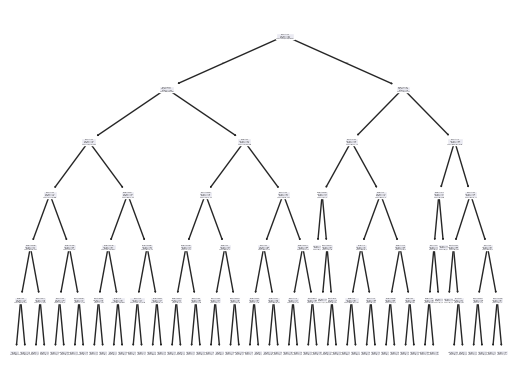

In [8]:
plot_tree(clf)

In [9]:
#Random Forest Model

rf = RandomForestClassifier(
    n_estimators=400,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=2,
    random_state=42,
    class_weight='balanced'
)

rf.fit(X_train, y_train)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [35]:

print("Train Accuracy:", rf.score(X_train, y_train))
print("Test Accuracy :", rf.score(X_test, y_test))
print("\nClassification Report:")
print(classification_report(y_test, rf.predict(X_test)))
print (roc_auc_score(y_train, rf.predict_proba(X_train), multi_class='ovo'))
print (roc_auc_score(y_test, rf.predict_proba(X_test), multi_class='ovo'))

Train Accuracy: 0.8696612665684831
Test Accuracy : 0.8644939965694682

Classification Report:
              precision    recall  f1-score   support

           0       0.85      0.89      0.87       178
           1       0.95      0.66      0.78       143
           2       0.85      0.96      0.90       262

    accuracy                           0.86       583
   macro avg       0.88      0.84      0.85       583
weighted avg       0.87      0.86      0.86       583

0.9610391436972416
0.9629096923032937


In [11]:
importances = pd.Series(rf.feature_importances_, index=X.columns)\
    .sort_values(ascending=False)

print("\nTop 15 Features:")
print(importances.head(15))


Top 15 Features:
crosses_def_home              0.037423
crosses_att_away              0.035351
high_passes_att_away          0.032311
smart_passes_away_pct         0.030308
high_passes_def_home          0.028692
smart_passes_home_pct         0.028146
xg_overall_away               0.027340
crosses_home_pct              0.025965
simple_passes_att_away_pct    0.025283
crosses_away_pct              0.024868
simple_passes_att_home_pct    0.024312
overall_home                  0.024271
overall_away                  0.024132
xg_overall_home               0.023154
clearances_away_pct           0.021366
dtype: float64


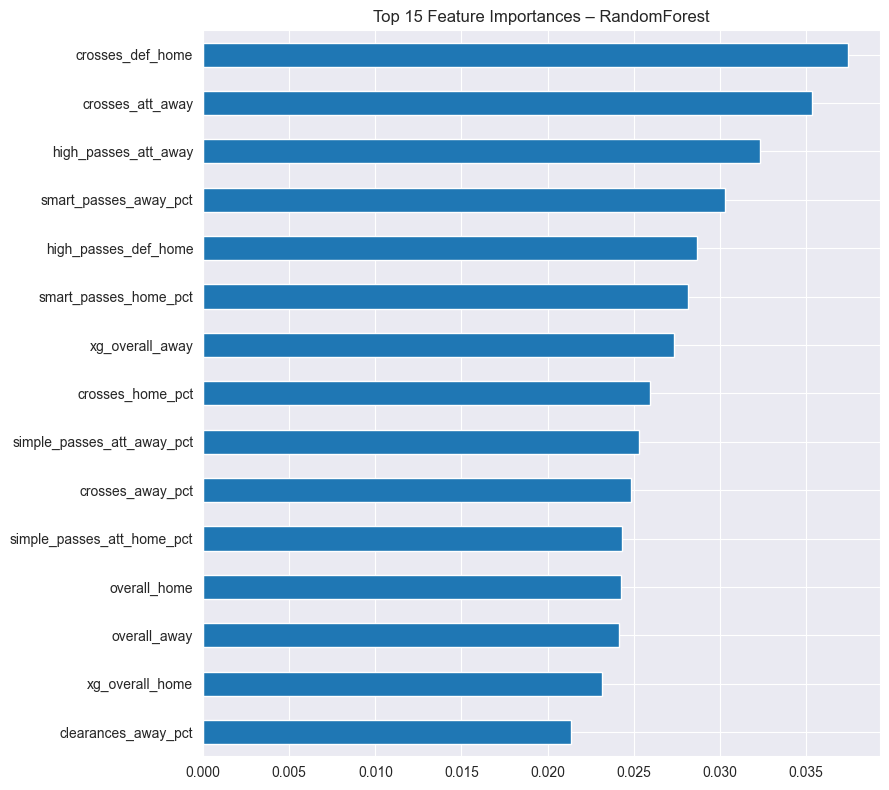

In [12]:
plt.figure(figsize=(9, 8))
importances.head(15).plot(kind='barh')
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances – RandomForest")
plt.tight_layout()
plt.show()

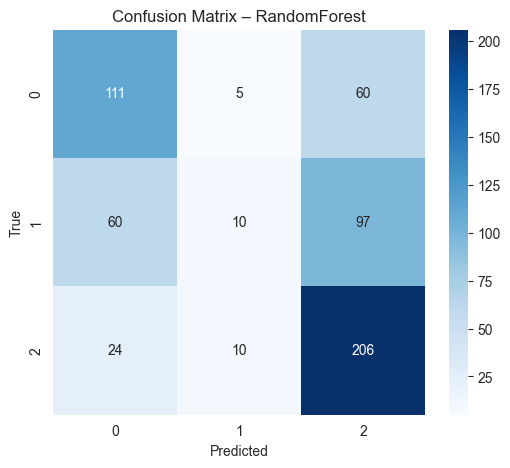

In [13]:
cm = confusion_matrix(y_test, rf.predict(X_test))

plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, cmap="Blues", fmt='d')
plt.title("Confusion Matrix – RandomForest")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

Train Accuracy: 1.0
Test Accuracy : 0.5934819897084048
1.0
0.7344988544919929

Classification Report:
              precision    recall  f1-score   support

    away_win       0.60      0.58      0.59       178
        draw       0.26      0.13      0.18       143
    home_win       0.66      0.85      0.75       262

    accuracy                           0.59       583
   macro avg       0.51      0.52      0.50       583
weighted avg       0.54      0.59      0.56       583



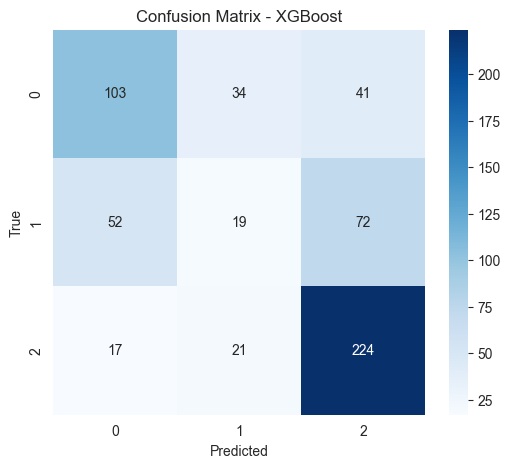

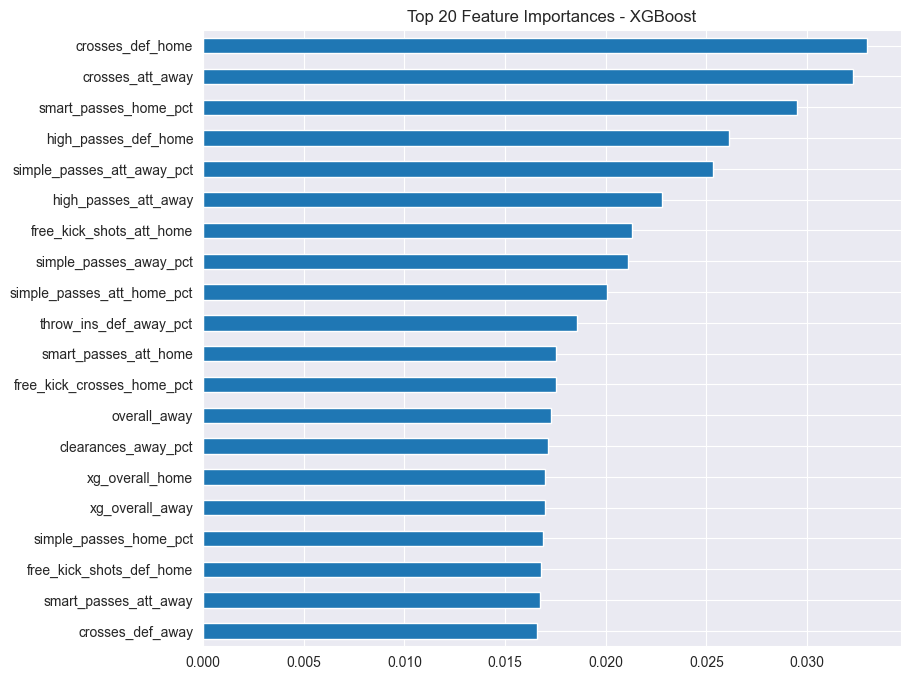

Top 5 XGBoost Features:
crosses_def_home              0.032991
crosses_att_away              0.032276
smart_passes_home_pct         0.029507
high_passes_def_home          0.026102
simple_passes_att_away_pct    0.025318
dtype: float32


In [36]:
#XGBoost
#df.columns = df.columns.str.replace('"', '')

le = LabelEncoder()
y = le.fit_transform(df['result'])

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.3,
    random_state=0,
    stratify=y
)

xgb = XGBClassifier(
    n_estimators=400,
    learning_rate=0.04,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.9,
    eval_metric='mlogloss',
    random_state=42
)

xgb.fit(X_train, y_train)

print("Train Accuracy:", xgb.score(X_train, y_train))
print("Test Accuracy :", xgb.score(X_test, y_test))
print (roc_auc_score(y_train, xgb.predict_proba(X_train), multi_class='ovo'))
print (roc_auc_score(y_test, xgb.predict_proba(X_test), multi_class='ovo'))

y_pred = xgb.predict(X_test)

print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=le.classes_))


# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.title("Confusion Matrix - XGBoost")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.show()

importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

plt.figure(figsize=(9, 8))
importances.head(20).plot(kind='barh')
plt.title("Top 20 Feature Importances - XGBoost")
plt.gca().invert_yaxis()
plt.show()

xgb_importances = pd.Series(
    xgb.feature_importances_,
    index=X.columns
).sort_values(ascending=False)

top5_xgb = xgb_importances.head(5)

print("Top 5 XGBoost Features:")
print(top5_xgb)

In [37]:
#Explainable Boosting Machine
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

# Train model
ebm = ExplainableBoostingClassifier(
    interactions=0,  # برای multiclass بهتر است 0 باشد
    max_rounds=5000,
    random_state=42
)

ebm.fit(X_train, y_train)

print("Train Accuracy:", ebm.score(X_train, y_train))
print("Test Accuracy :", ebm.score(X_test, y_test))

print (roc_auc_score(y_train, ebm.predict_proba(X_train), multi_class='ovo'))
print (roc_auc_score(y_test, ebm.predict_proba(X_test), multi_class='ovo'))

#===========================
#  Feature Importance (Correct Method)
#===========================
# Global explanation
global_exp = ebm.explain_global()
data = global_exp.data()

# Extract feature names & importance (OLD API)
feature_names = data['names']
feature_importance = data['scores']

# Build dataframe
importance_df = pd.DataFrame({
    'feature': feature_names,
    'importance': feature_importance
}).sort_values(by='importance', ascending=False)

print("\nTop Features:")
print(importance_df.head(20))

importance_df.head(20)

/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/interpret/glassbox/_ebm/_ebm.py:872: UserWarning: Missing values detected. Our visualizations do not currently display missing values. To retain the glassbox nature of the model you need to either set the missing values to an extreme value like -1000 that will be visible on the graphs, or manually examine the missing value score in ebm.term_scores_[term_index][0]
  warn(


Train Accuracy: 0.6671575846833578
Test Accuracy : 0.6123499142367067
0.8267769995765182
0.7538519818518102

Top Features:
                       feature  importance
34            crosses_def_home    0.133160
39            crosses_att_away    0.132413
22        high_passes_def_home    0.104233
27        high_passes_att_away    0.070972
37            crosses_def_away    0.067532
8        smart_passes_home_pct    0.045730
51  simple_passes_att_away_pct    0.045110
9        smart_passes_away_pct    0.042637
50  simple_passes_att_home_pct    0.042407
11            crosses_away_pct    0.042048
10            crosses_home_pct    0.040565
63             xg_overall_away    0.037105
61                overall_away    0.035696
16  free_kick_crosses_home_pct    0.035549
20            corners_home_pct    0.034222
53         clearances_away_pct    0.032984
52         clearances_home_pct    0.032357
7         high_passes_away_pct    0.029359
25        high_passes_def_away    0.028853
6         high_pa

,feature,importance
34,crosses_def_home,0.133160
39,crosses_att_away,0.132413
22,high_passes_def_home,0.104233
27,high_passes_att_away,0.070972
37,crosses_def_away,0.067532
8,smart_passes_home_pct,0.045730
51,simple_passes_att_away_pct,0.045110
9,smart_passes_away_pct,0.042637
50,simple_passes_att_home_pct,0.042407
11,crosses_away_pct,0.042048


In [22]:
from sklearn.metrics import roc_auc_score, accuracy_score
import pandas as pd

results = []

def compute_metrics(model, name):
    """Helper function to compute train/test accuracy and AUC."""
    # Train predictions
    pred_train = model.predict(X_train)
    prob_train = model.predict_proba(X_train)

    # Test predictions
    pred_test = model.predict(X_test)
    prob_test = model.predict_proba(X_test)

    # Append results
    return [
        name,
        accuracy_score(y_train, pred_train),
        roc_auc_score(y_train, prob_train, multi_class='ovr'),
        accuracy_score(y_test, pred_test),
        roc_auc_score(y_test, prob_test, multi_class='ovr')
    ]


# ---------------------
# Decision Tree
# ---------------------

results.append(compute_metrics(clf, "Decision Tree"))

# ---------------------
# Random Forest
# ---------------------
results.append(compute_metrics(rf, "Random Forest"))

# ---------------------
# XGBoost
# ---------------------
results.append(compute_metrics(xgb, "XGBoost"))

# ---------------------
# Explainable Boosting Machine (EBM)
# ---------------------
results.append(compute_metrics(ebm, "Explainable Boosting Machine"))

# ---------------------
# Build results table
# ---------------------
results_df = pd.DataFrame(results, columns=[
    "Model",
    "Train set Accuracy", "Train set AUC",
    "Test set Accuracy", "Test set AUC"
])

print(results_df)
results_df

                          Model  Train set Accuracy  Train set AUC  \
0                 Decision Tree            0.637703       0.774555   
1                 Random Forest            0.869661       0.963036   
2                       XGBoost            0.879234       0.967454   
3  Explainable Boosting Machine            0.667158       0.838860   

   Test set Accuracy  Test set AUC  
0           0.619211      0.772112  
1           0.864494      0.965326  
2           0.874786      0.977855  
3           0.612350      0.767145  


,Model,Train set Accuracy,Train set AUC,Test set Accuracy,Test set AUC
0,Decision Tree,0.637703,0.774555,0.619211,0.772112
1,Random Forest,0.869661,0.963036,0.864494,0.965326
2,XGBoost,0.879234,0.967454,0.874786,0.977855
3,Explainable Boosting Machine,0.667158,0.838860,0.612350,0.767145
